In [31]:
import pandas as pd 
import shap
import numpy as np

In [22]:
import sys
import os
sys.path.insert(0, os.path.abspath('..'))
from src.data_loader import load_data

from src.modeling import (
    train_linear_regression,
    train_random_forest,
    train_xgboost,
    prepare_model_data
)

In [3]:
df = load_data(
    "../data/MachineLearningRating_v3.txt"
)

### Random Forest Claim Severity Model

A Random Forest Regressor was trained to predict TotalClaims using vehicle, geographic, and policy-related variables.

#### Modeling Objectives

- Estimate claim severity
- Identify important pricing risk factors
- Support underwriting decision-making
- Improve actuarial segmentation

#### Features Used

- Province
- VehicleType
- Vehicle make and model
- VehicleAge
- SumInsured
- Engine power characteristics

In [7]:
results = train_random_forest(df)
results

{'model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('encoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['Province', 'VehicleType',
                                                    'make', 'Model']),
                                                  ('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['VehicleAge', 'SumInsured',
                                                

In [6]:
xgb_results = train_xgboost(df)
xgb_results

{'model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('encoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['Province', 'VehicleType',
                                                    'make', 'Model']),
                                                  ('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['VehicleAge', 'SumInsured',
                                                

In [4]:
linear_results = train_linear_regression(df)

linear_results

{'model': Pipeline(steps=[('preprocessor',
                  ColumnTransformer(transformers=[('cat',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='most_frequent')),
                                                                   ('encoder',
                                                                    OneHotEncoder(handle_unknown='ignore'))]),
                                                   ['Province', 'VehicleType',
                                                    'make', 'Model']),
                                                  ('num',
                                                   Pipeline(steps=[('imputer',
                                                                    SimpleImputer(strategy='median'))]),
                                                   ['VehicleAge', 'SumInsured',
                                                

### Model Comparison Analysis

The ensemble-based machine learning models demonstrate the ability to capture complex nonlinear relationships in insurance risk data. XGBoost and Random Forest are particularly effective for highly skewed claim distributions and heterogeneous policyholder characteristics.

In [14]:
comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "XGBoost"
    ],

    "RMSE": [
        linear_results["rmse"],
        results["rmse"],
        xgb_results["rmse"]
    ],

    "R2": [
        linear_results["r2"],
        results["r2"],
        xgb_results["r2"]
    ]
})

comparison

,Model,RMSE,R2
0,Linear Regression,2210.460690,0.000051
1,Random Forest,2349.679117,-0.129872
2,XGBoost,2279.309137,-0.063209


In [15]:
best_model = xgb_results["model"]

In [26]:
preprocessor = best_model.named_steps[
    "preprocessor"
]

xgb_model = best_model.named_steps[
    "model"
]

In [17]:
feature_names = preprocessor.get_feature_names_out()

### SHAP Feature Importance Analysis

SHAP explainability identifies the most influential variables driving claim severity predictions. Vehicle characteristics, geographic location, insured value, and vehicle age emerge as critical pricing determinants for underwriting decision-making.

In [23]:
X, y, _ = prepare_model_data(df)

In [27]:
X_transformed = preprocessor.transform(X)

In [28]:
explainer = shap.Explainer(
    xgb_model
)

shap_values = explainer(
    X_transformed[:1000]
)

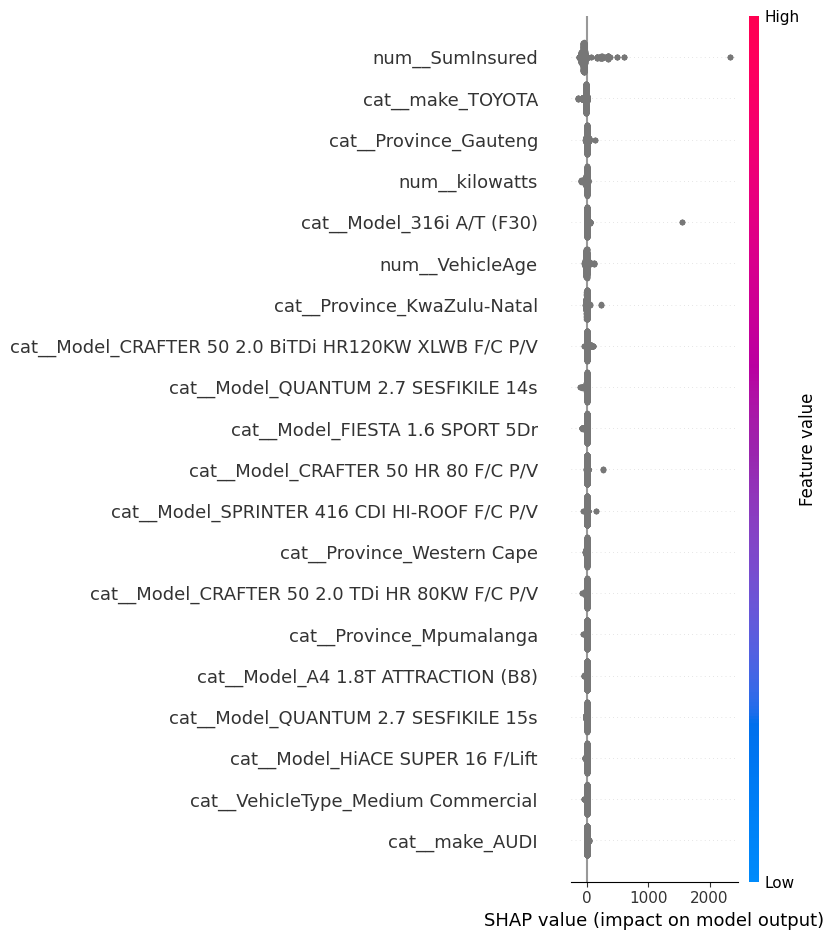

In [29]:
shap.summary_plot(
    shap_values,
    X_transformed[:1000],
    feature_names=feature_names
)

In [32]:
importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": np.abs(
        shap_values.values
    ).mean(axis=0)
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
461,num__SumInsured,95.557434
53,cat__make_TOYOTA,14.094069
2,cat__Province_Gauteng,9.327722
462,num__kilowatts,8.782998
64,cat__Model_316i A/T (F30),8.364368
460,num__VehicleAge,8.272032
3,cat__Province_KwaZulu-Natal,6.818568
215,cat__Model_CRAFTER 50 2.0 BiTDi HR120KW XLWB F...,6.763797
342,cat__Model_QUANTUM 2.7 SESFIKILE 14s,4.550637
243,cat__Model_FIESTA 1.6 SPORT 5Dr,2.653764
